# (18) generate: mnist conv

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def quick_print_sparse_scores(z):
    life, pop, portions = sparse_score(z, cutoff=0.01)

    life = life.mean(1)
    pop = pop.mean(0)
    portion_zeros = (z[:, -1, :] == 0.0).mean()

    msg = ',  '.join([
        f"\n\n% zeros = {portion_zeros * 100:0.1f}",
        f"lifetime = {life[-1] * 100:0.1f}",
        f"population = {pop[-1] * 100:0.1f}",
        f"\n\nAll portions:\n{portions}\n",
    ])
    print(msg)
    
    return


def do_the_plots(samples_x, nrows_time=16, nrows=8, **kwargs):
    defaults = dict(
        dpi=300,
        cmap='Greys_r',
        method='min-max',
        display=False,
        pad=0,
    )
    kwargs = setup_kwargs(defaults, kwargs)

    # (1) plot generative process across time
    shape = (-1, *tr.model.cfg.input_sz[1:])
    x2p = samples_x[range(nrows_time)].reshape(shape)
    fig_time, _ = plot_weights(x2p, nrows=nrows_time, **kwargs)
    # (2) plot generated sampels (last time point)
    x2p = samples_x[:, -1]
    fig_samples, _ = plot_weights(x2p, nrows=nrows, **kwargs)
    # (3) return
    figs_dict = {
        'generated_samples': fig_samples,
        'generation_across_time': fig_time,
    }
    return figs_dict


In [3]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Load model

In [4]:
a = 'poisson_MNIST_t-16_b-2_k-64_<ngd|conv>'
b = 'b200-ep400-lr(0.002)_temp(0.05:0.5)_gr(150)_(2025_05_29,08:13)'
tr, meta = load_model(pjoin(a, b), device)

meta['checkpoint']

400

In [5]:
tr.print()

poisson_MNIST_t-16_b-2_k-64_<ngd|conv>
b200-ep400-lr(0.002)_temp(0.05)_gr(150)_(2025_05_29,08:13)

## Generate w/ different x_init

In [6]:
n_samples = 256
t_total = 50

### x_init = None

In [7]:
x_init = None

samples_x, samples_z = tr.model.generate(
    x_init=x_init,
    n_samples=n_samples,
    t_total=t_total,
)

In [8]:
quick_print_sparse_scores(samples_z)

% zeros = 40.9,  lifetime = 66.8,  population = 67.0,  

All portions:
{'0': 36.0, '1': 21.3, '2': 12.9, '3': 8.3, '4': 5.6, '5': 4.0, '6': 2.9, '7': 2.2, '8': 1.7, '9': 1.3, '10': 1.0, 
'11+': 2.8}

generated_samples

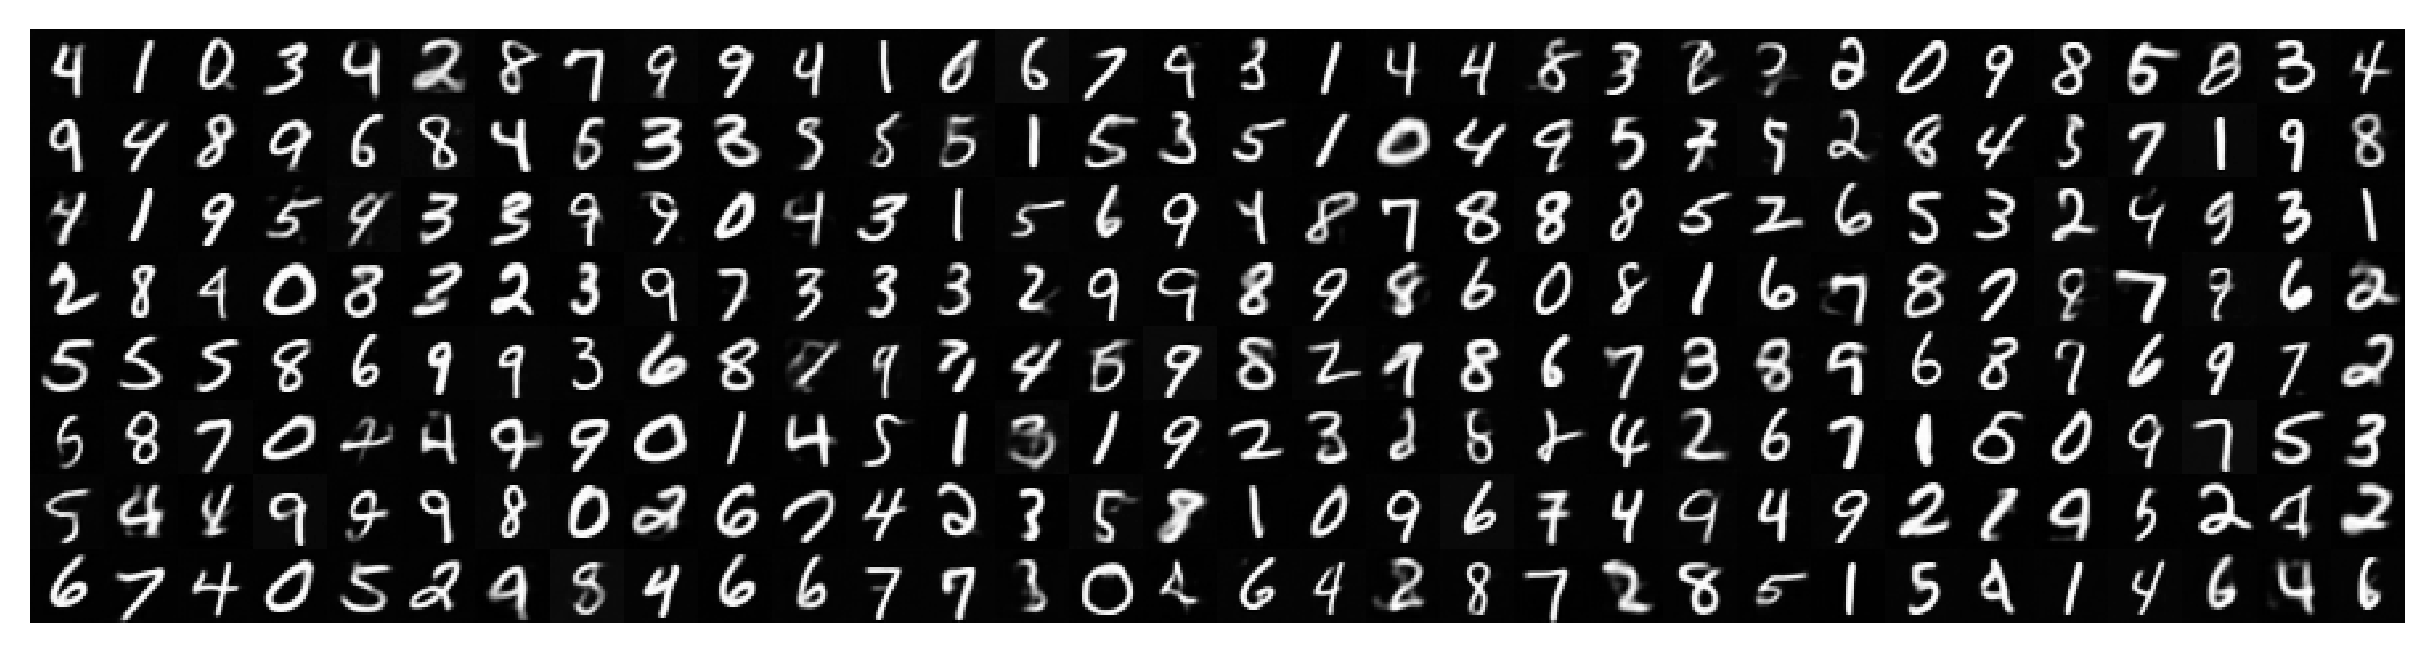

generation_across_time

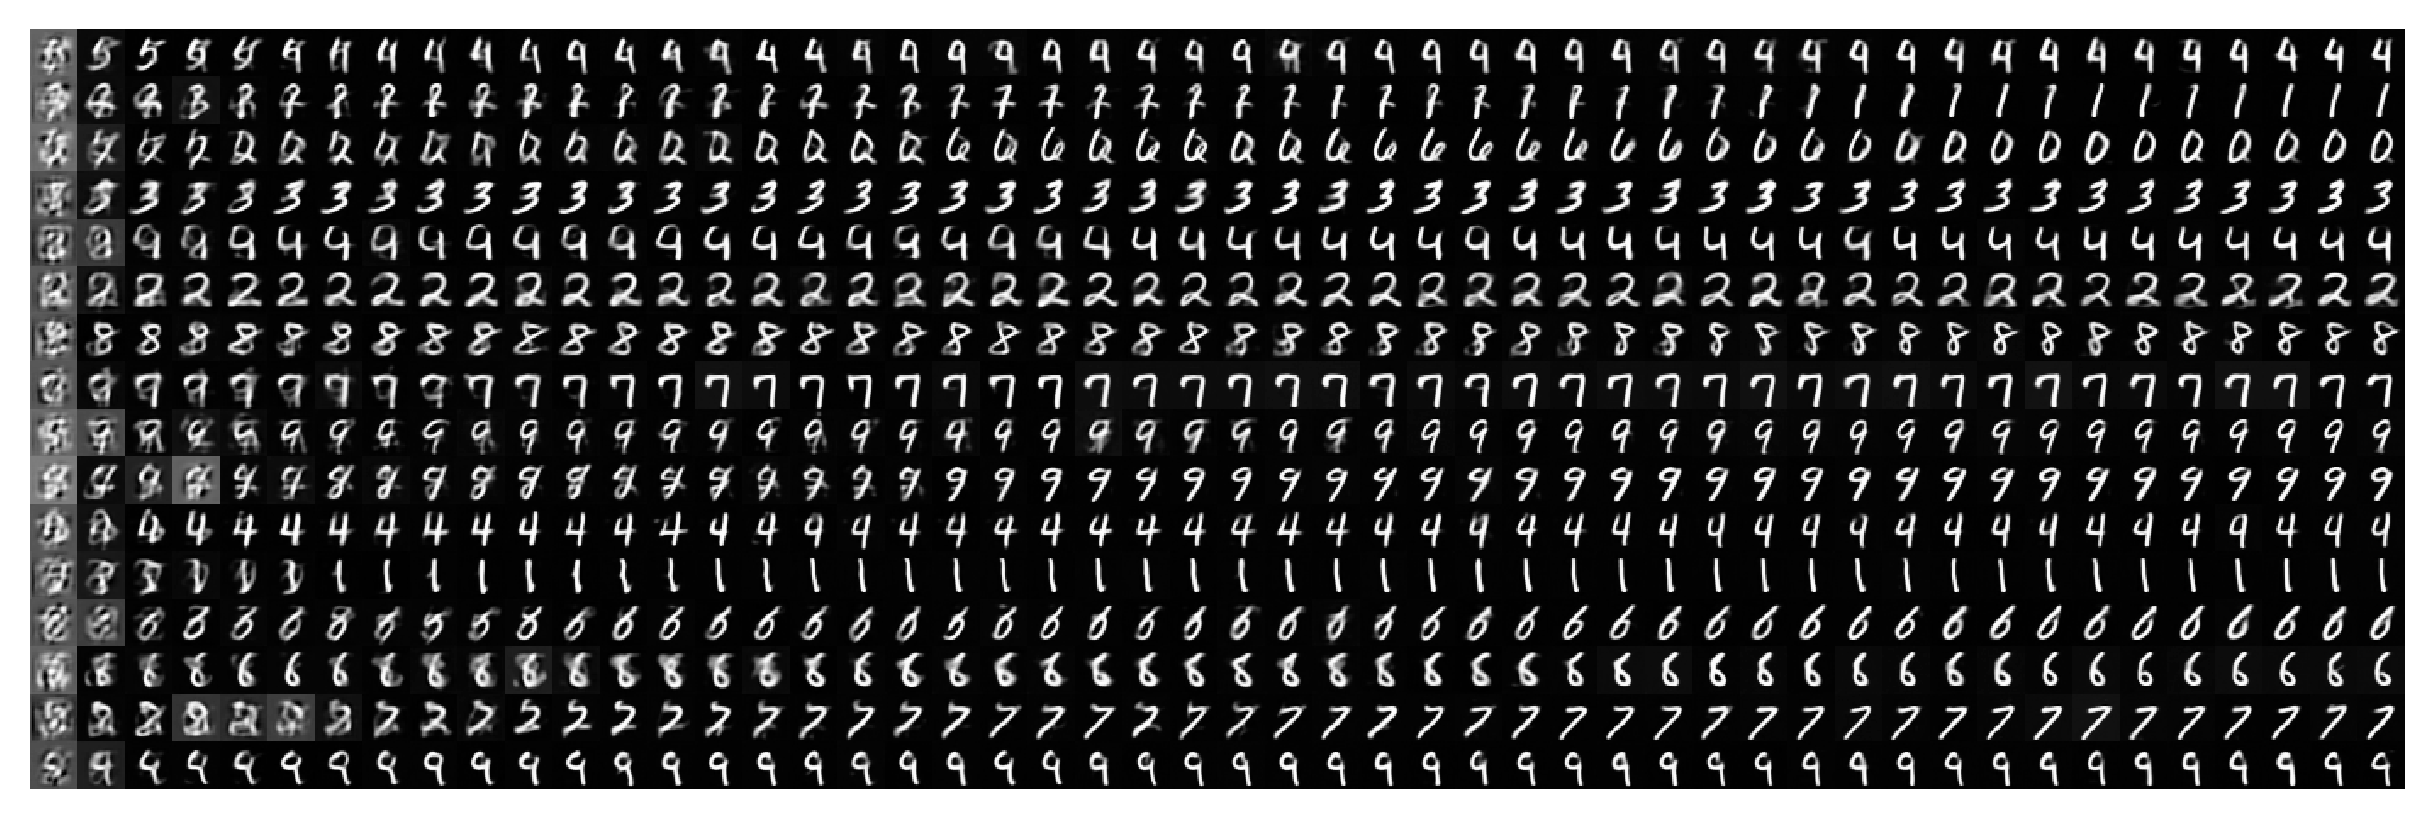

In [9]:
figs_dict = do_the_plots(samples_x)

for k, fig in figs_dict.items():
    print(k)
    display(fig)

### x_init = zeros

In [10]:
x_init = torch.zeros((1, np.prod(tr.model.cfg.input_sz)))
x_init = tr.to(x_init)

samples_x, samples_z = tr.model.generate(
    x_init=x_init,
    n_samples=n_samples,
    t_total=t_total,
)

In [11]:
quick_print_sparse_scores(samples_z)

% zeros = 43.9,  lifetime = 60.8,  population = 67.6,  

All portions:
{'0': 37.5, '1': 20.3, '2': 13.3, '3': 9.2, '4': 6.3, '5': 4.3, '6': 2.9, '7': 2.0, '8': 1.4, '9': 0.9, '10+': 2.0}

/home/hadi/Dropbox/git/_iclr_ipvae/figures/imgs.py:140: RuntimeWarning: invalid value encountered in divide
  x_nrm = numen / denum


generated_samples

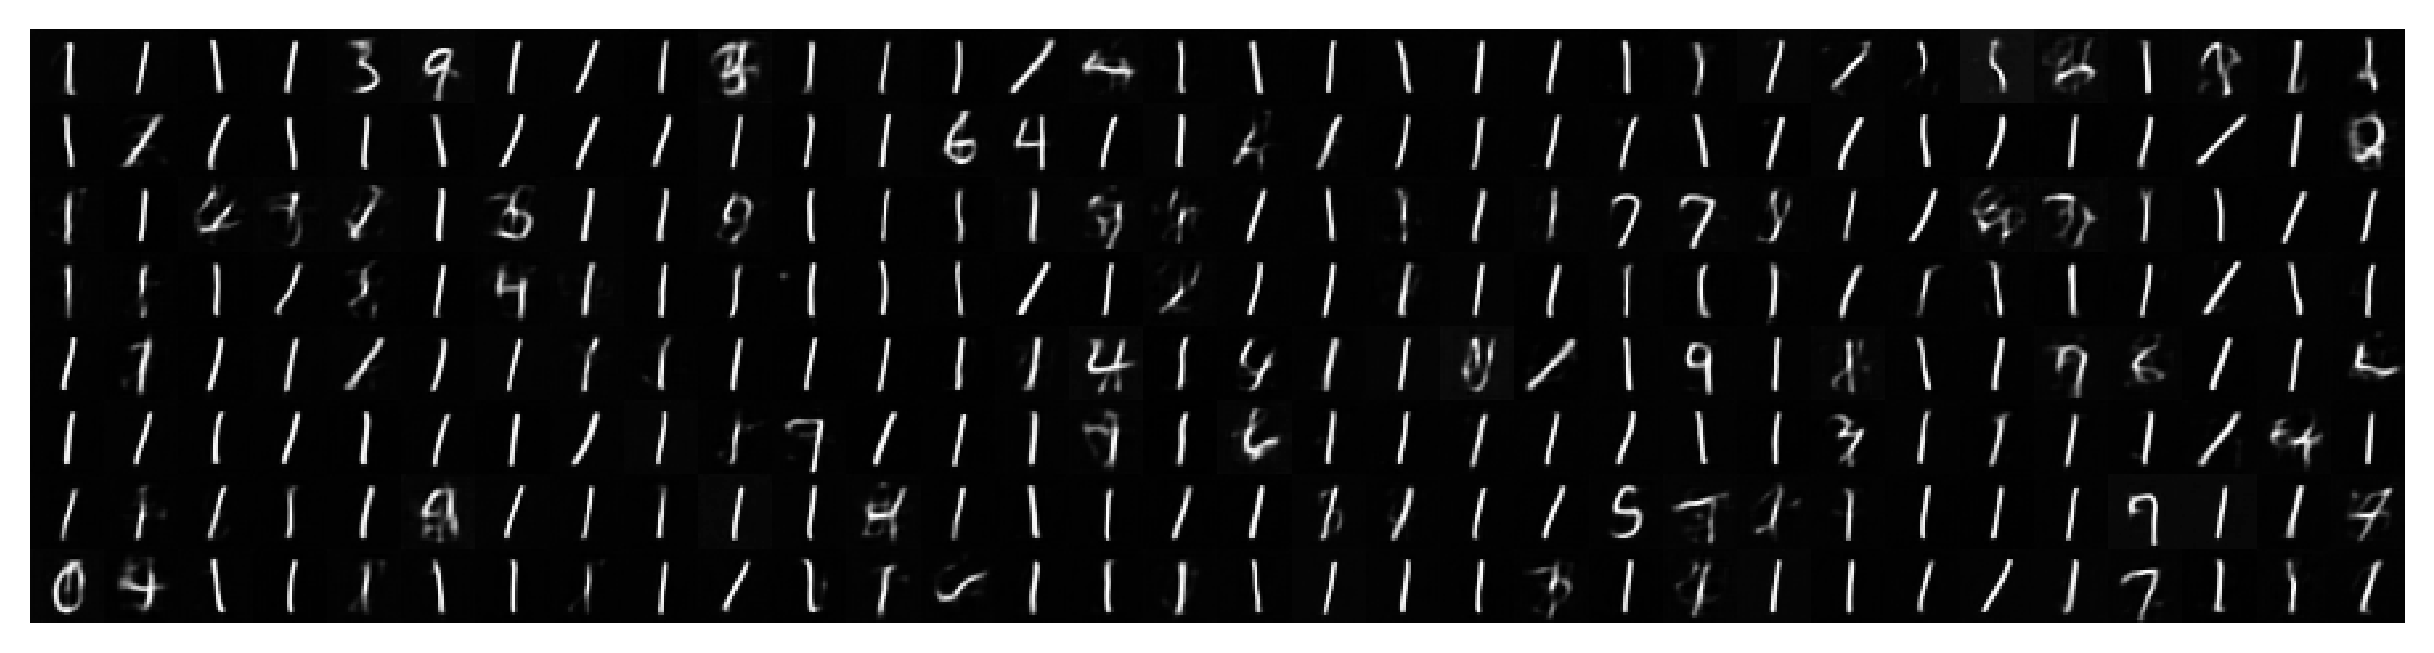

generation_across_time

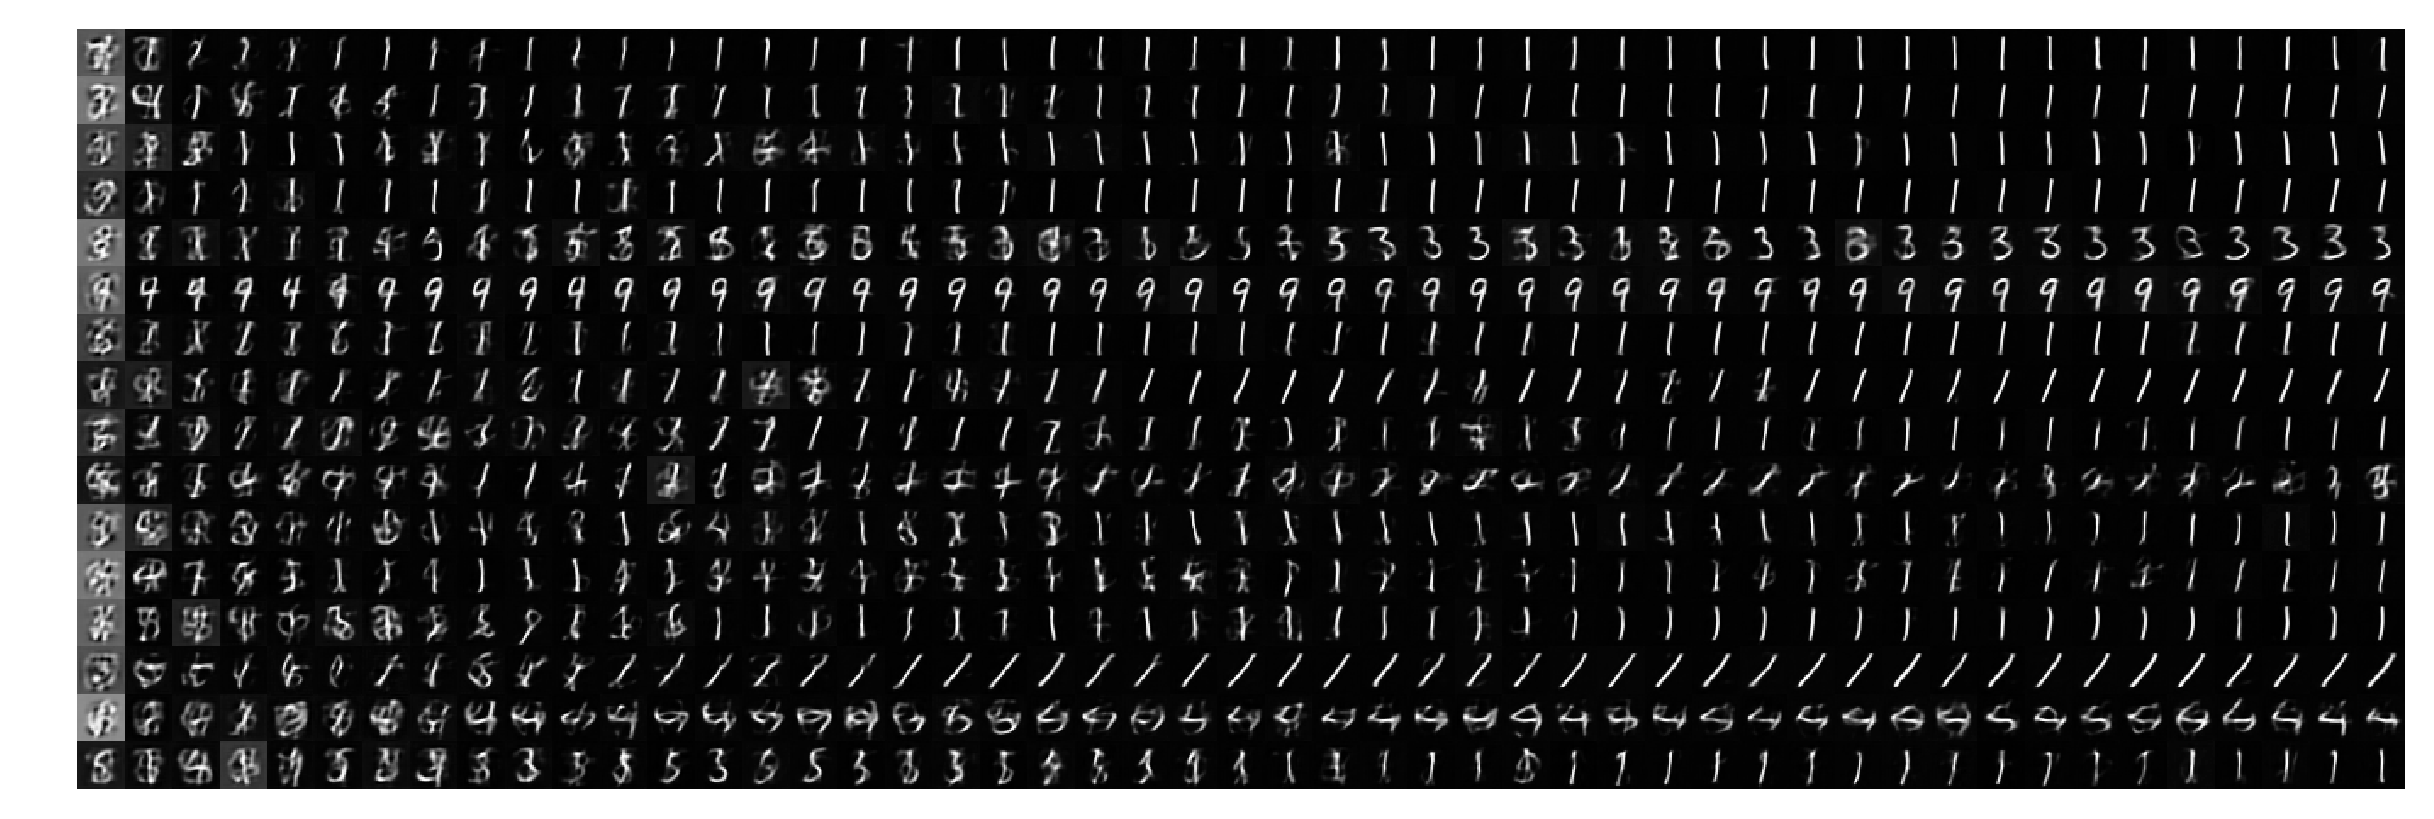

In [12]:
figs_dict = do_the_plots(samples_x)

for k, fig in figs_dict.items():
    print(k)
    display(fig)

### x_init = noise

In [13]:
sigma = 1.0
x_init = torch.randn((n_samples, np.prod(tr.model.cfg.input_sz))) * sigma
x_init = tr.to(x_init)

samples_x, samples_z = tr.model.generate(
    x_init=x_init,
    n_samples=n_samples,
    t_total=t_total,
)

In [14]:
quick_print_sparse_scores(samples_z)

% zeros = 36.8,  lifetime = 60.5,  population = 63.6,  

All portions:
{'0': 32.2, '1': 20.5, '2': 13.3, '3': 9.2, '4': 6.5, '5': 4.8, '6': 3.6, '7': 2.7, '8': 2.0, '9': 1.5, '10': 1.1, 
'11': 0.8, '12+': 2.0}

generated_samples

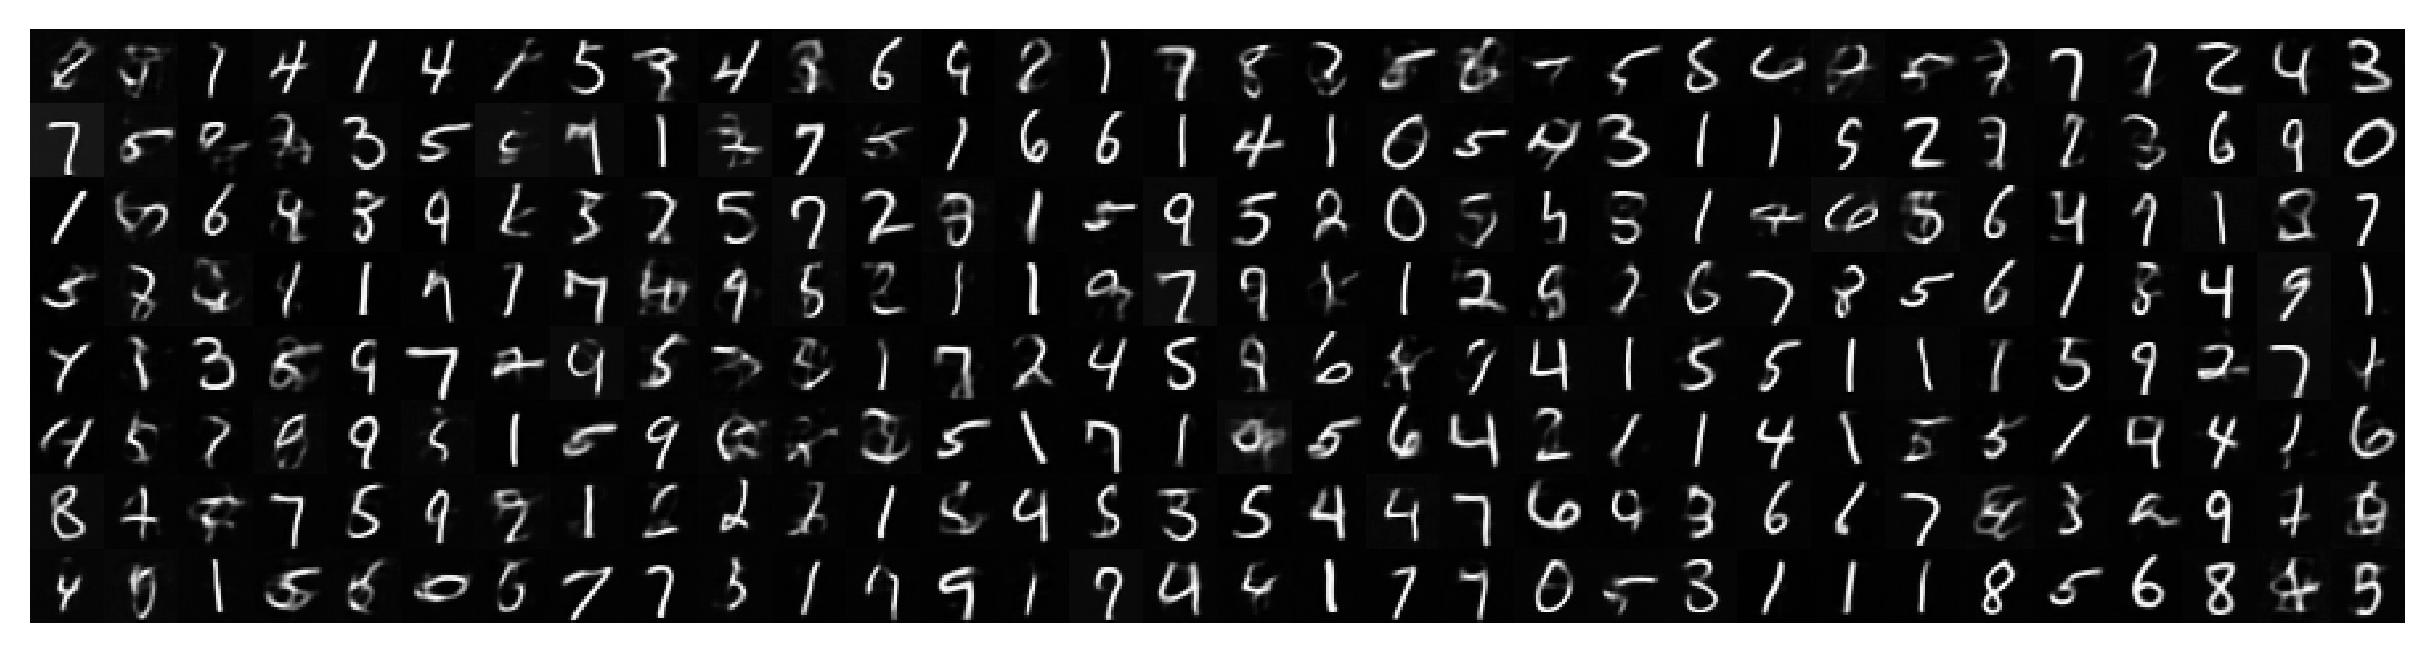

generation_across_time

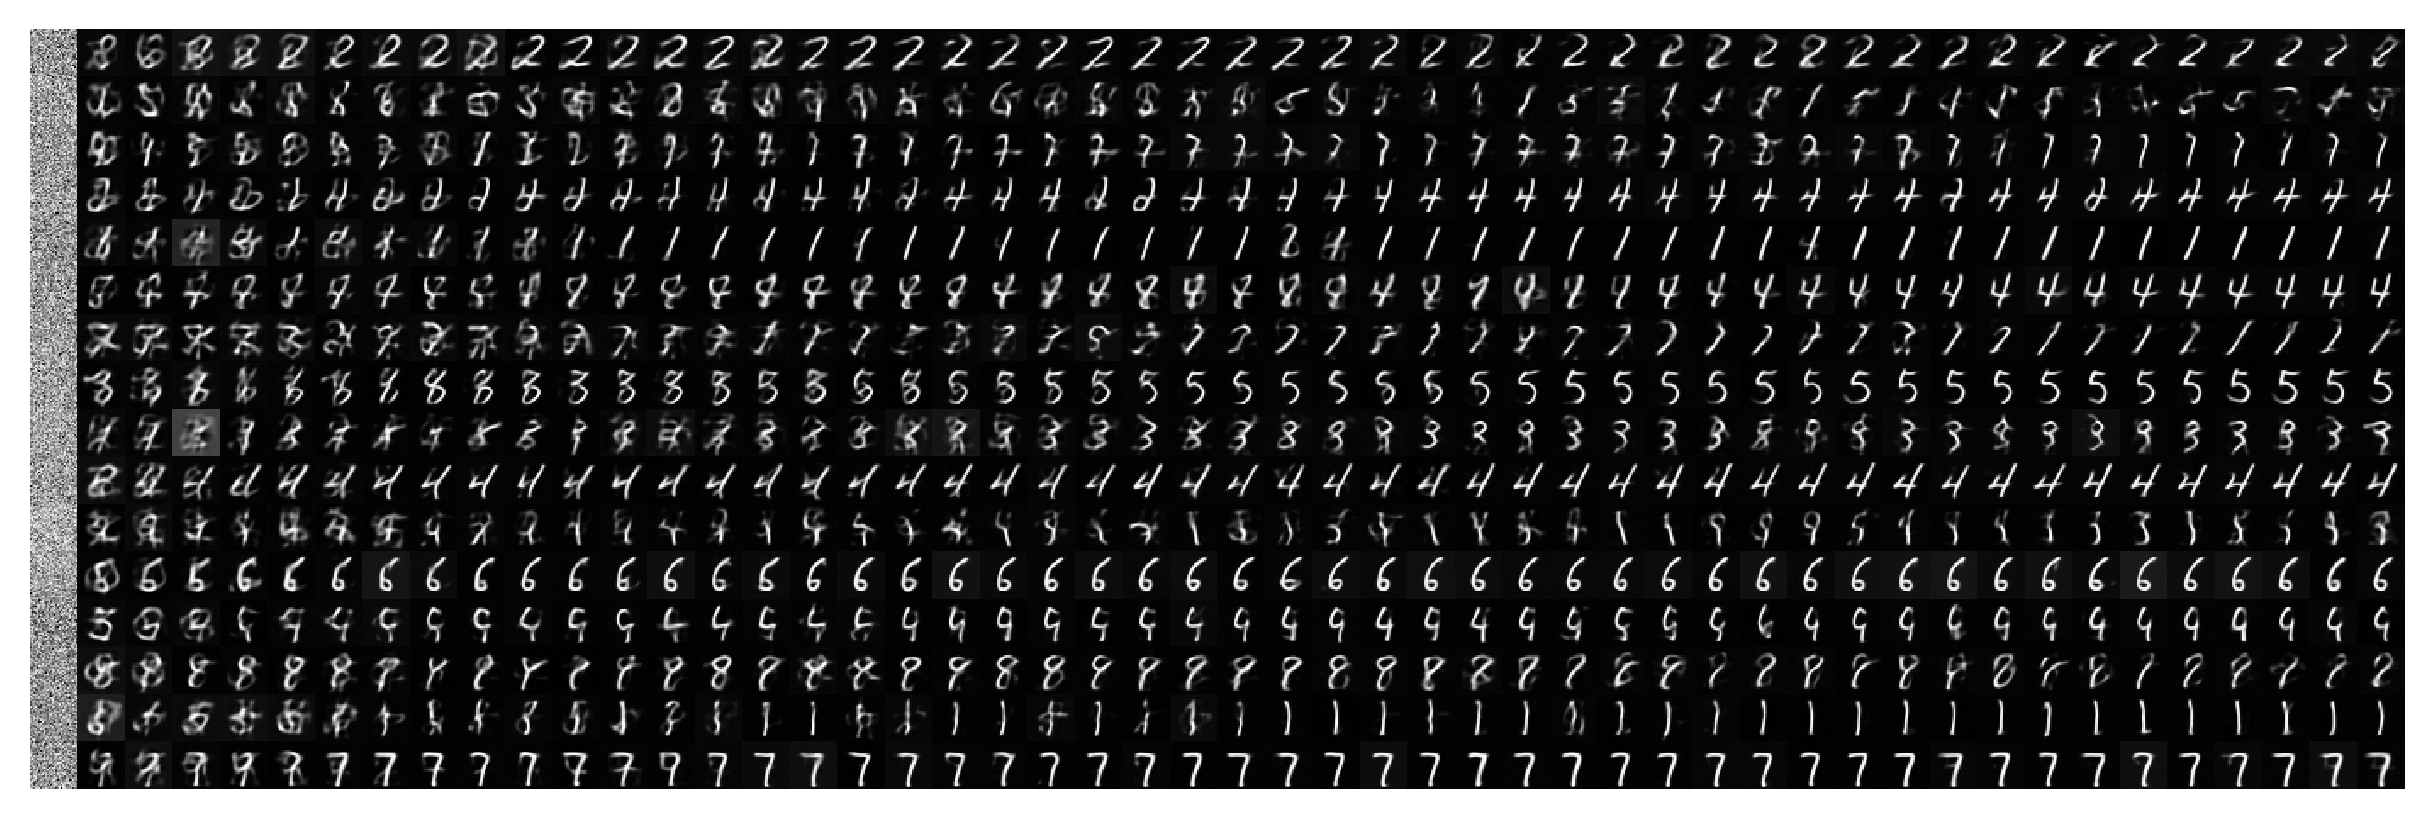

In [15]:
figs_dict = do_the_plots(samples_x)

for k, fig in figs_dict.items():
    print(k)
    display(fig)

## Sanity check

### Figs: Recon + Generation

In [16]:
figs = {}
kws = dict(pad=0, display=False)

figs['recon'] = tr.show_recon(**kws)
figs.update(tr.show_samples(**kws))

recon

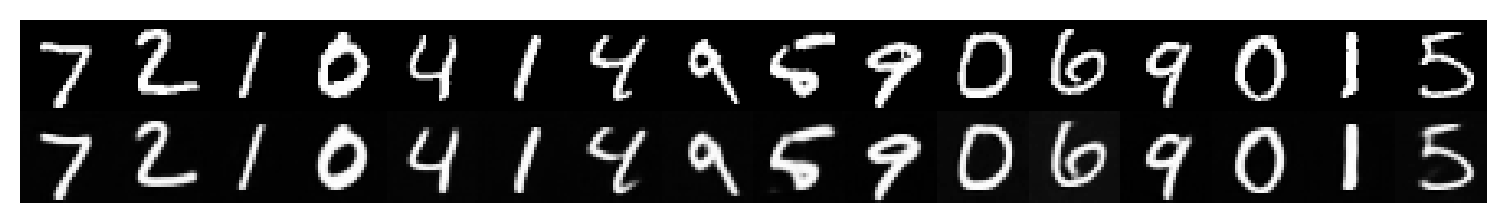

generated_samples

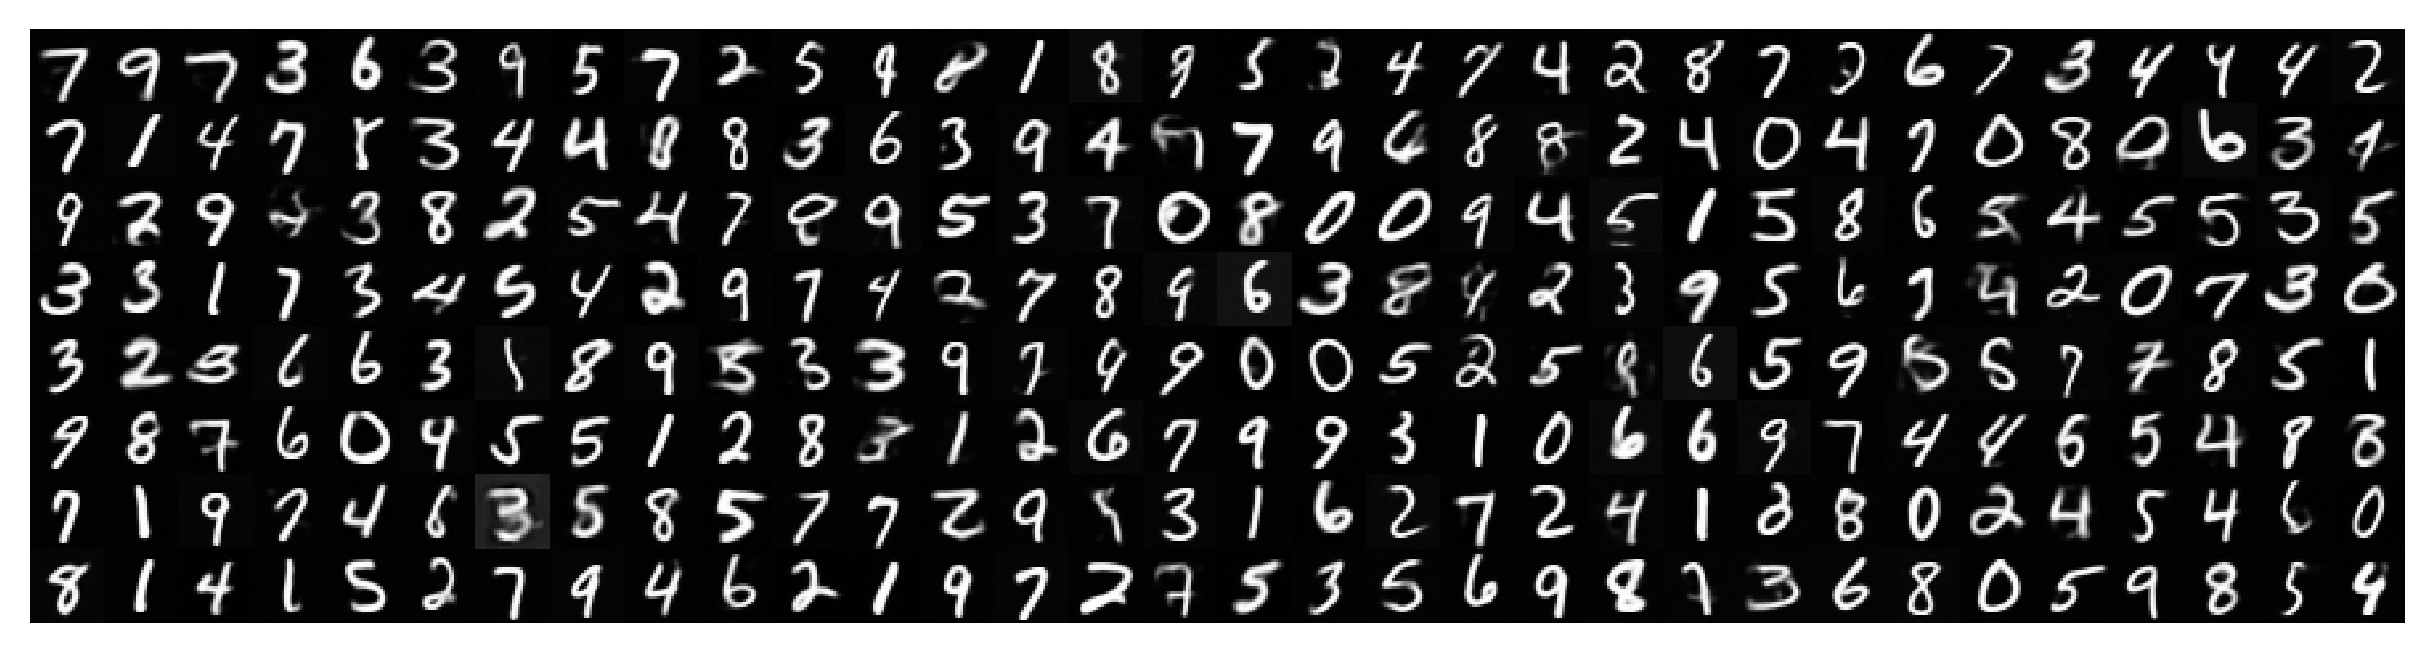

generation_across_time

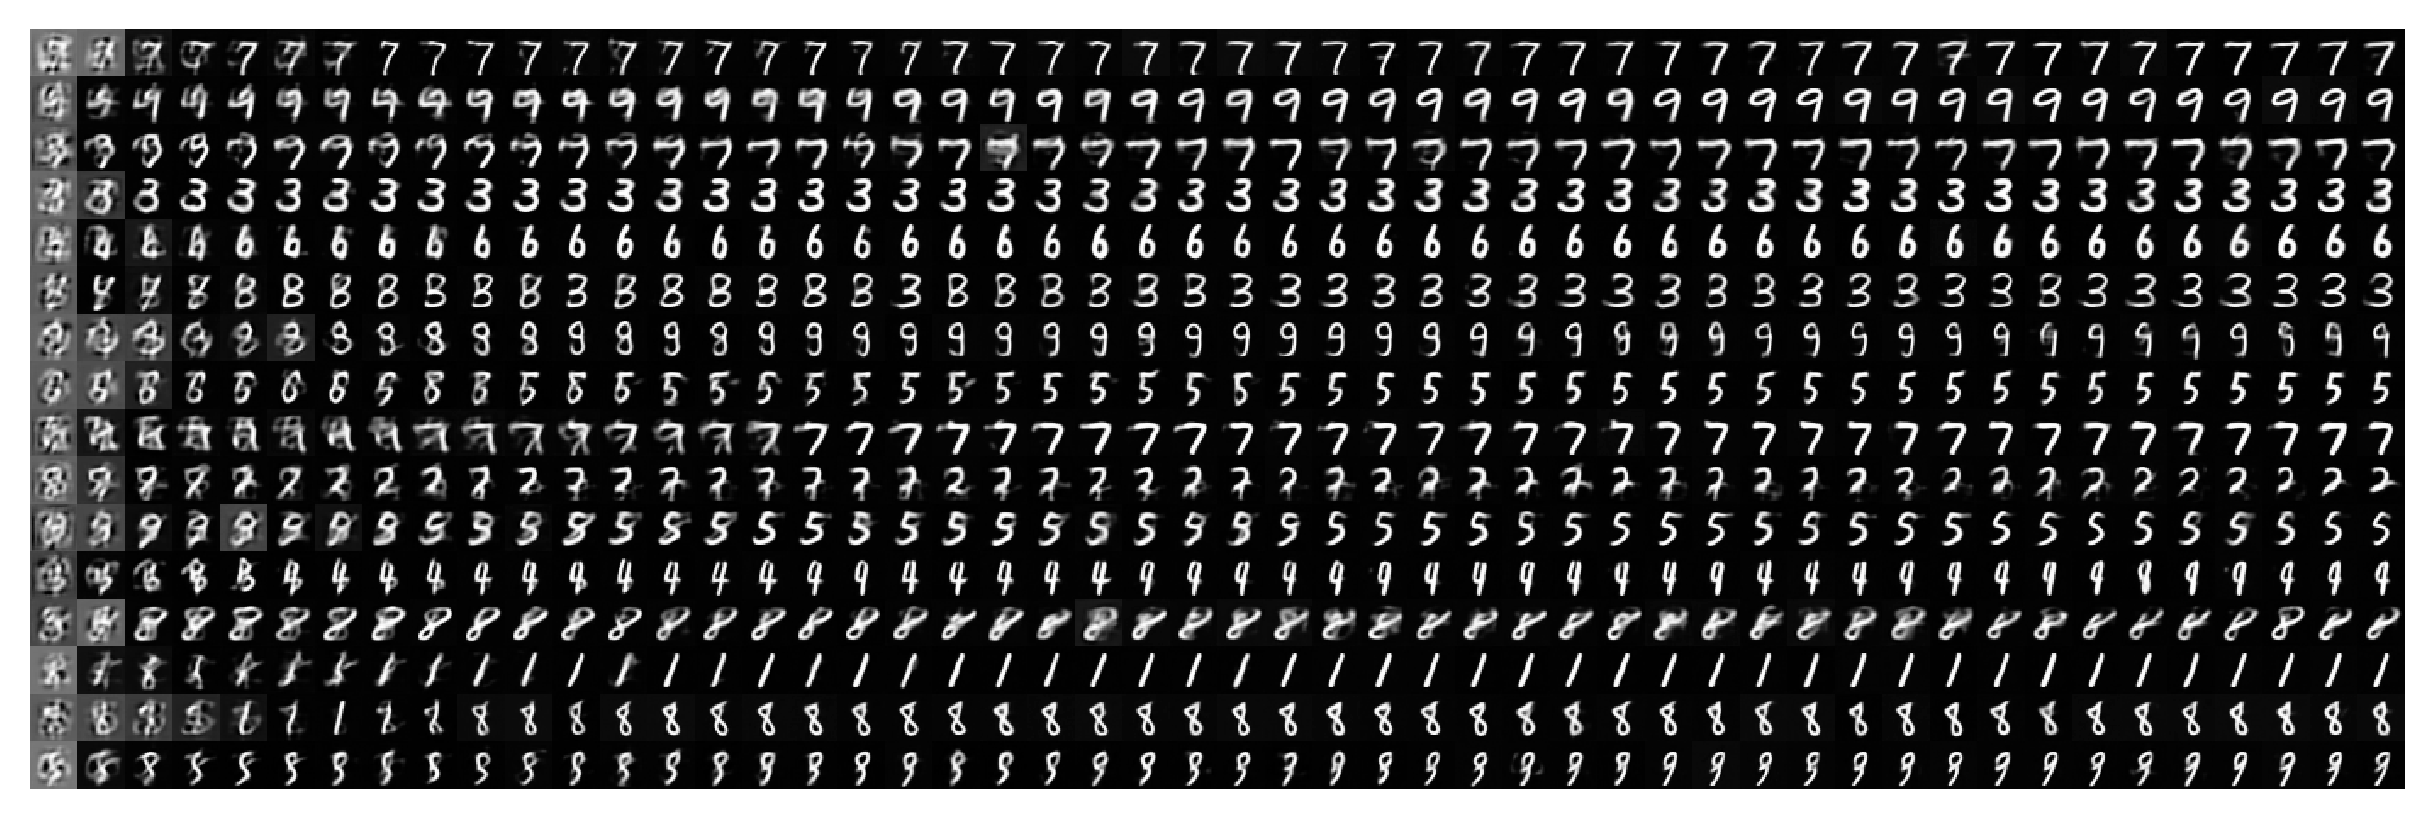

In [17]:
for k, f in figs.items():
    print(k)
    display(f)

### Performance

100%|█████████████████████████████████| 50/50 [11:26<00:00, 13.74s/it]


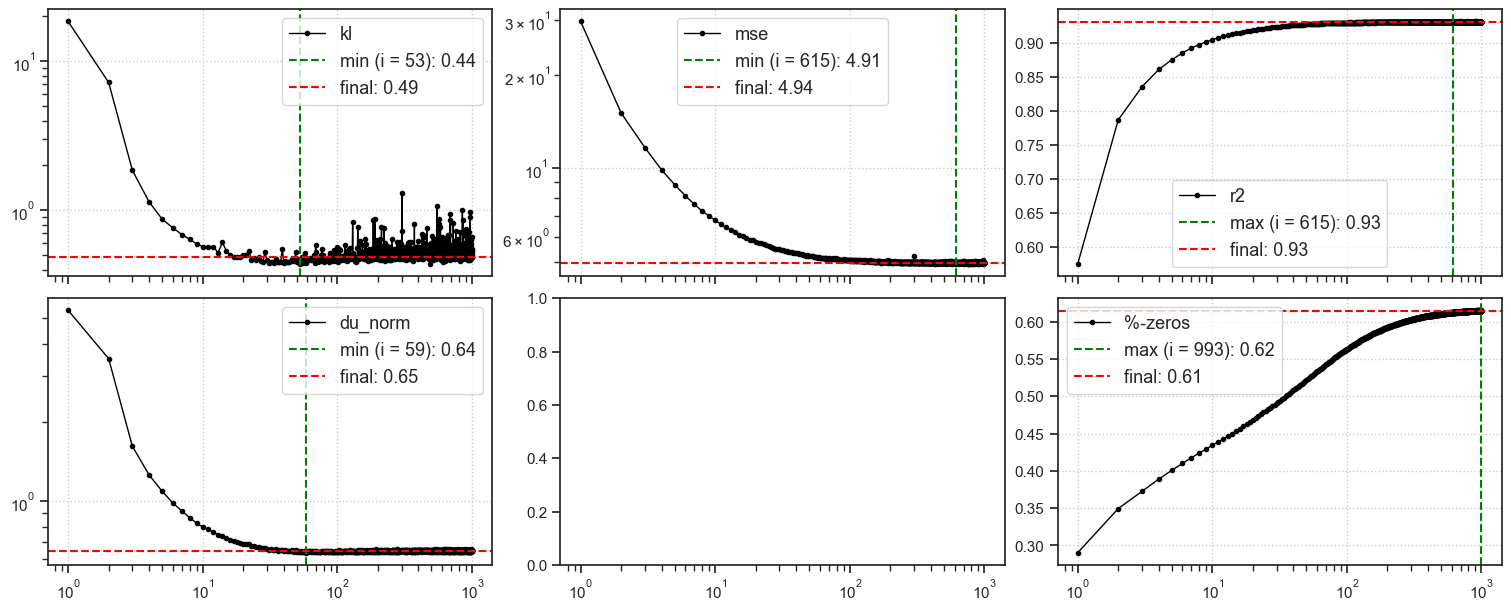

CPU times: user 11min 30s, sys: 1.17 s, total: 11min 31s
Wall time: 11min 31s


In [18]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=-1,
)
_ = plot_convergence(results, color='k')